In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support, precision_score, recall_score, f1_score)
from sklearn.model_selection import train_test_split
import seaborn as sn
import pandas as pd
from ultralytics import YOLO
from pathlib import Path
import random
import shutil
import cv2
from skimage import io, color, filters

# Q1. Object detection and depth estimation                             20+5+20 = 45 points
 Use L515 camera in Lab to acquire rgb video and depth video (e.g. 30 s) of swinging load in lab (rgb_train_val_swingingload.avi; depth_train_val_swingingload.avi). Extract each frames from rgb video. Use the extracted images to train and validate YOLO model (save as YOLO_swinging_load.pt). Record test_swingingload.avi (e.g. 5 s). Extract frames and use them as test data set. Test your YOLO model (YOLO_swinging_load.pt) on this test data set.

(a) Show the performance of your model on test data set by plotting relevant KPIs.

(b) Sample five random images from test data video (test_swingingload.avi). Find the center, and coordinates of bounding box. Display them on the each test image.

(c) realsense_acq.ipynb contains code that streams, rgb, and depth video. Based on this code, extract the frames from depth_train_val_swingingload.avi. Each pixel in each frame consists of depth information of corresponding rgb images. As described in Q1.b find the center of bounding box of ALL frames in  test video (test_swingingload.avi). Display its center and corresponding depth.


References: Use Ultralytics framework for help - https://docs.ultralytics.com/tasks/detect
Realsense - https://dev.realsenseai.com/sdk-2-0-code-samples-wrappers-and-languages/opencv/ 


In [8]:
# Which steps to run. Annotate/dataset/train only need to run once.
DO_ANNOTATE = True
DO_DATASET  = True
DO_TRAIN    = True
DO_EVAL     = True      # Q1 a) b) c)

DEBUG = False            # show plots for annotation and evaluation

# Directories and paths
HERE = Path.cwd()                       # Notebook runs from the folder it is saved in
classDir   = HERE / "Assignment 1-class"
datasetDir = HERE / "Q1" / "dataset"
dataYaml   = HERE / "data.yaml"
modelPath  = HERE / "YOLO_swinging_load.pt"
outputDir  = HERE / "runs"
outputDir.mkdir(exist_ok=True)

# Annotation parameters for background subtraction
DIFF_THRESH = 55        # |I - B| above this is 'moving' (0-255)
SIGMA       = 1.5       # Gaussian smoothing of the difference image
RADIUS      = 70        # mask pixels farther than this from the centre are ignored

confTresh  = 0.5        # Confidence threshold for detection
depthScale = 0.00025    # L515: metres per raw depth unit (check against realsense_acq.ipynb)
random.seed(0)


def to_gray(path):
    img = io.imread(str(path))[..., :3]
    return img, color.rgb2gray(img).astype(np.float32) * 255  # M x N x 3 -> M x N, 0-255


def find_payload(gray, background):
    diff = filters.gaussian(np.abs(gray - background), sigma=SIGMA, preserve_range=True)
    rows, cols = np.where(diff > DIFF_THRESH)
    if rows.size == 0:
        return None, None
    center_x, center_y = cols.mean(), rows.mean()                       # Finding payload by finding the mean of the pixels of the picture
    near = np.hypot(cols - center_x, rows - center_y) < RADIUS          # Adding filter for outliers - removing pixels far from the load (rope, shadows)
    cols, rows = cols[near], rows[near]                                 # Applying the filter to the pixels
    center_x, center_y = int(cols.mean()), int(rows.mean())             # Recalculate the center after filtering
    x1, y1, x2, y2 = cols.min(), rows.min(), cols.max(), rows.max()     # box = extent of the mask
    return (center_x, center_y), (x1, y1, x2 - x1, y2 - y1)             # Returning the center and the box (x, y, w, h)

In [9]:
# 1. Annotate -> YOLO labels ------------------------------------------------------------------------
if DO_ANNOTATE:
    for split in ("train", "test"):
        framesDir, labelsDir = classDir / split / "rgb_frames", classDir / split / "labels"
        labelsDir.mkdir(exist_ok=True)
        files = sorted(framesDir.glob("*.png"))

        if any(labelsDir.glob("*.txt")):
            print(f"{split}: labels already exist ({len(list(labelsDir.glob('*.txt')))} files), skipping")  # Skipping labeling if labels already exist
            continue

        print(f"{split}: annotating...")
        background = np.median(np.stack([to_gray(f)[1] for f in files[::1]]), axis=0)   # Finding median background from every 5th frame (to avoid moving load)

        log = []
        for i, f in enumerate(files):
            img, gray = to_gray(f)                          # Getting the grayscale image
            H, W = gray.shape                               # Getting the height and width of the image
            center, box = find_payload(gray, background)    # Finding the center and the box of the load
            if box is None:
                log.append((np.nan, np.nan, np.nan, np.nan)); continue
            
            x, y, w, h = box                                                                                            # Getting the box coordinates
            (labelsDir / f"{f.stem}.txt").write_text(f"0 {(x + w/2)/W:.6f} {(y + h/2)/H:.6f} {w/W:.6f} {h/H:.6f}\n")    # Writing the YOLO label file with the class (0) and normalized coordinates of the box
            log.append((*center, w, h))

        log = np.array(log, dtype=float)                                                # Converting the log to a numpy array
        print(f"{split}: {(~np.isnan(log[:, 0])).sum()}/{len(files)} labels written")   # Showing how many labels were written out of the total number of frames

        if DEBUG:
            fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
            ax[0].plot(log[:, 0], label="center_x"); ax[0].plot(log[:, 1], label="center_y"); ax[0].legend(); ax[0].set_ylabel("px")
            ax[1].plot(log[:, 2], label="w");        ax[1].plot(log[:, 3], label="h");        ax[1].legend(); ax[1].set_ylabel("px")
            ax[1].set_xlabel("frame"); fig.suptitle(f"{split} annotation check"); plt.tight_layout(); plt.show()

train: annotating...
train: 600/600 labels written
test: annotating...
test: 150/150 labels written


In [10]:
# 2. Dataset folder + data.yaml ---------------------------------------------------------------------
if DO_DATASET:
    def copy(files, split):
        (datasetDir / "images" / split).mkdir(parents=True, exist_ok=True)  # Making the directories for the dataset images
        (datasetDir / "labels" / split).mkdir(parents=True, exist_ok=True)  # Making the directories for the dataset labels
        for img in files:
            shutil.copy(img, datasetDir / "images" / split / img.name)      # Copying the images to the dataset folder
            shutil.copy(img.parent.parent / "labels" / f"{img.stem}.txt", datasetDir / "labels" / split / f"{img.stem}.txt")  # Copying the labels to the dataset folder

    def labelled(split):    # Checking which frames have labels and returning the list of those frames
        return [f for f in sorted((classDir / split / "rgb_frames").glob("*.png"))
                if (classDir / split / "labels" / f"{f.stem}.txt").exists()] 

    train, test = labelled("train"), labelled("test")
    random.shuffle(train)
    nVal = int(0.2 * len(train))
    copy(train[nVal:], "train"); copy(train[:nVal], "val"); copy(test, "test")

    dataYaml.write_text(
        f"path: {datasetDir.as_posix()}\n"
        "train: images/train\n"
        "val: images/val\n"
        "test: images/test\n"
        "names:\n"
        "  0: Payload\n"
    )   # Writing the data.yaml file with the paths to the dataset and the class names

    print(f"dataset: train {len(train) - nVal}, val {nVal}, test {len(test)}")

dataset: train 480, val 120, test 150


In [11]:
# 3. Train -----------------------------------------------------------------------------------------
if DO_TRAIN:
    model = YOLO("yolo11n.pt")      # Loading the YOLO model
    model.train(data=dataYaml,  
                epochs=100, 
                imgsz=640, 
                batch=32, 
                patience=10, 
                project=outputDir, 
                name="swinging_load", 
                exist_ok=True)          # Parameters for training the YOLO model                  
    shutil.copy(outputDir / "swinging_load" / "weights" / "best.pt", modelPath) # Copying the best model weights to the modelPath
    print(f"Saved model to: {modelPath}")

Ultralytics 8.4.165  Python-3.10.21 torch-2.14.0+cpu CPU (AMD Ryzen 9 9900X 12-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\ssgje\Documents\School\MAS512 - Computer Vision and Embedded AI\Assignments\MAS512\Assignment 1\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937

Ultralytics 8.4.165  Python-3.10.21 torch-2.14.0+cpu CPU (AMD Ryzen 9 9900X 12-Core Processor)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 115.422.0 MB/s, size: 518.1 KB)
val: Scanning C:\Users\ssgje\Documents\School\MAS512 - Computer Vision and Embedded AI\Assignments\MAS512\Assignment 1\Q1\dataset\labels\test... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 603.2it/s 0.2s0.2s
val: New cache created: C:\Users\ssgje\Documents\School\MAS512 - Computer Vision and Embedded AI\Assignments\MAS512\Assignment 1\Q1\dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 4.4it/s 2.3s.3s
                   all        150        150      0.898      0.887       0.92      0.312
Speed: 0.5ms preprocess, 8.3ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\ssgje\Documents\School\MAS512

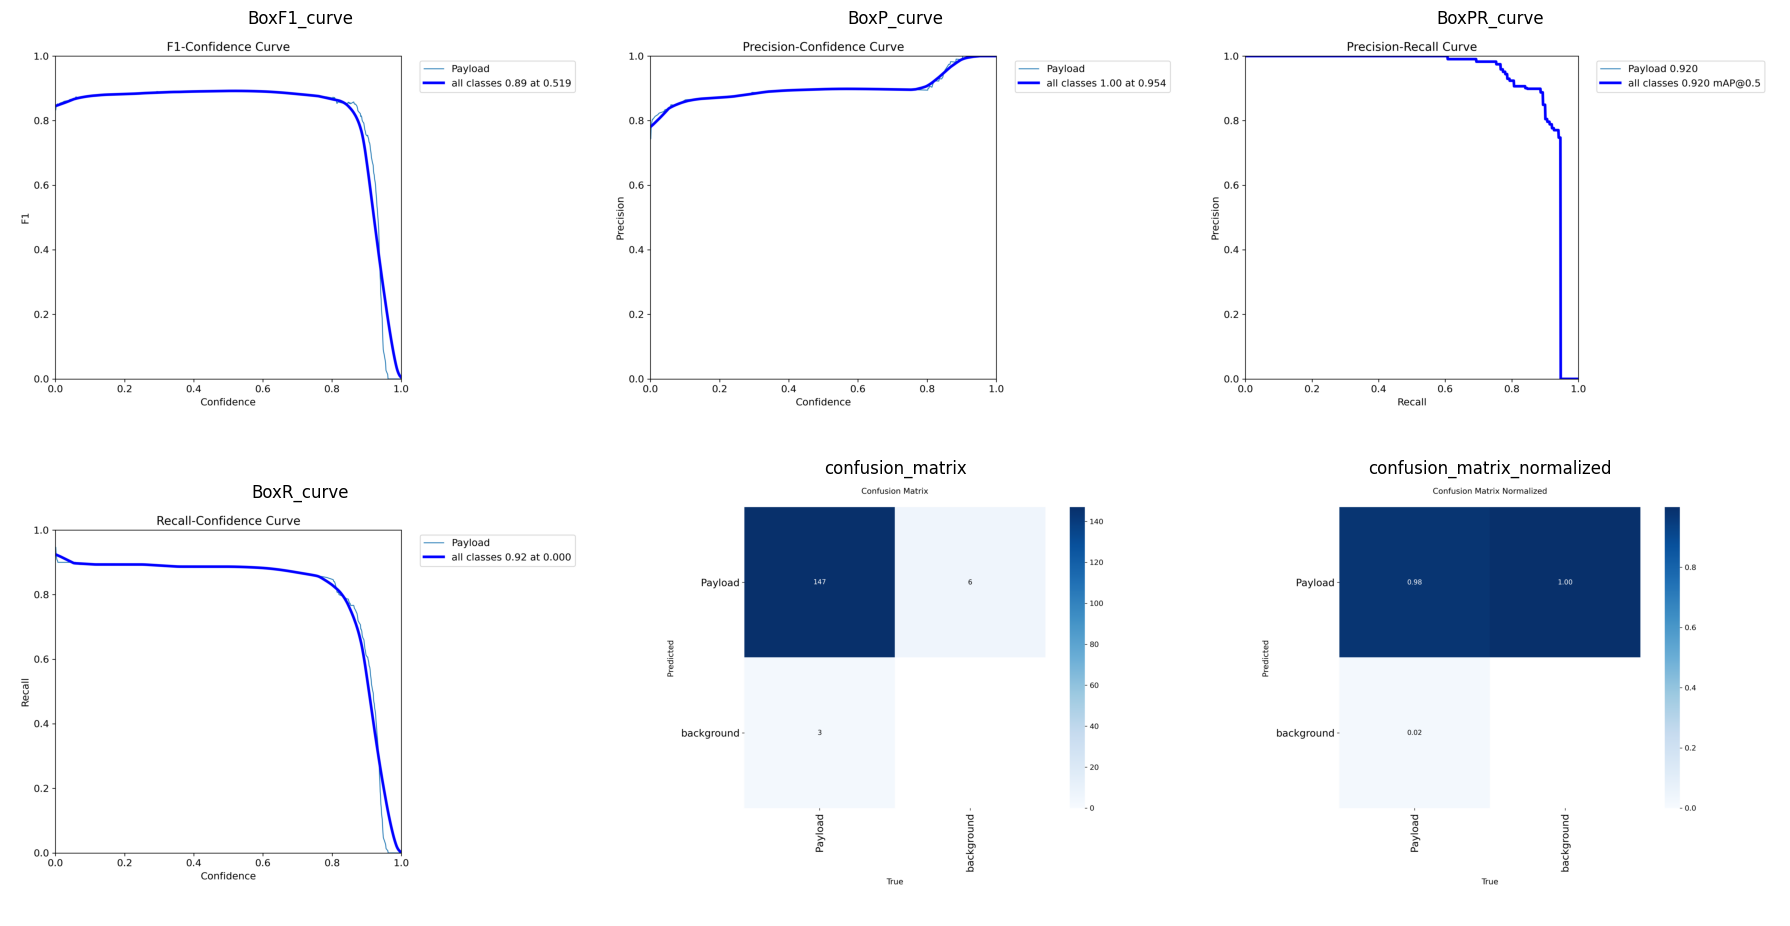

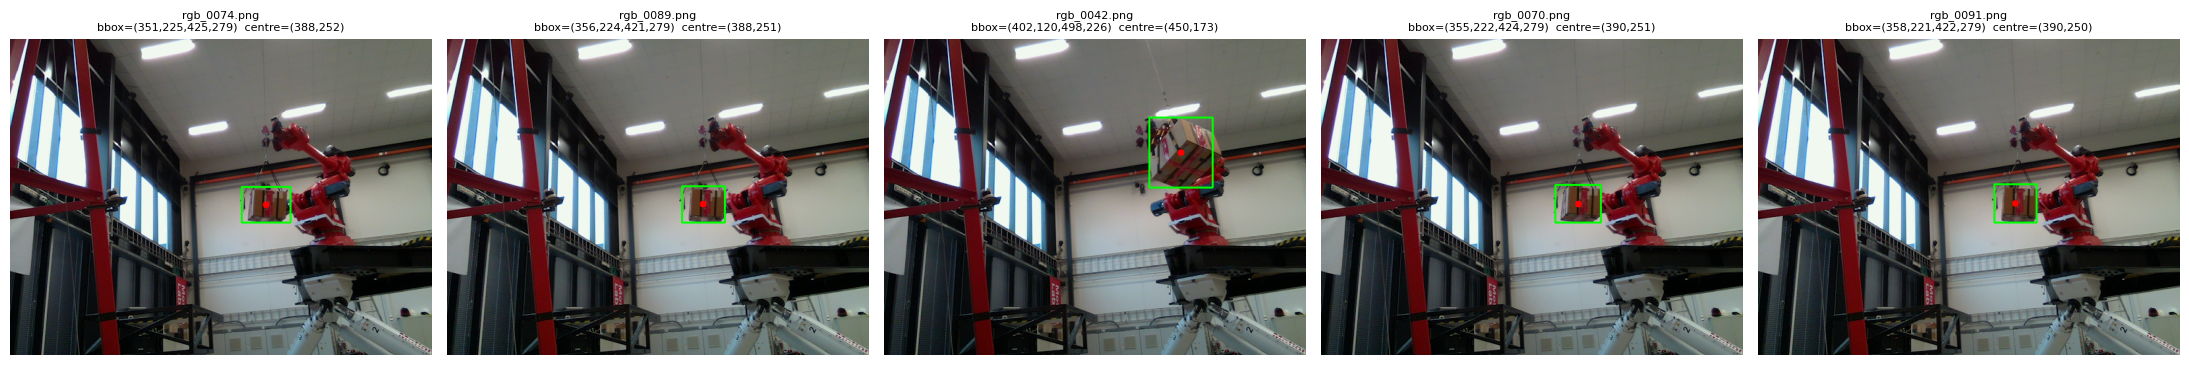

150 frames, load detected in 147, depth valid in 145
frame    0   centre=( 387,  236)   depth=3.855 m
frame    1   centre=( 391,  236)   depth=3.827 m
frame    2   centre=( 395,  236)   depth=3.781 m
frame    3   centre=( 396,  237)   depth=3.748 m
frame    4   centre=( 396,  236)   depth=3.730 m
frame    5   centre=( 397,  235)   depth=3.700 m
frame    6   centre=( 398,  233)   depth=3.653 m
frame    7   centre=( 401,  233)   depth=3.629 m
frame    8   centre=( 403,  232)   depth=3.596 m
frame    9   centre=( 405,  231)   depth=3.584 m
frame   10   centre=( 407,  230)   depth=3.522 m
frame   11   centre=( 410,  228)   depth=3.529 m
frame   12   centre=( 412,  227)   depth=3.444 m
frame   13   centre=( 416,  226)   depth=3.425 m
frame   14   centre=( 418,  225)   depth=3.371 m
frame   15   centre=( 419,  222)   depth=3.344 m
frame   16   centre=( 423,  219)   depth=3.284 m
frame   17   centre=( 426,  215)   depth=3.256 m
frame   18   centre=( 427,  212)   depth=3.257 m
frame   19   cen

In [12]:
# 4. Q1 a) b) c) -----------------------------------------------------------------------------------
if DO_EVAL:
    model = YOLO(modelPath)                         # Loading the trained YOLO model
    testFrames = classDir / "test" / "rgb_frames"   # Getting the test frames directory
    depthDir   = classDir / "test" / "depth_raw"    # Getting the depth frames directory
    files = sorted(testFrames.glob("*.png"))        # Getting the list of test frames

    def detect(frame):
        result = model.predict(frame, conf=confTresh, verbose=False)[0]
        if not len(result.boxes):
            return None
        box = result.boxes[result.boxes.conf.argmax()]
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        return int(x1), int(y1), int(x2), int(y2), int((x1 + x2) / 2), int((y1 + y2) / 2)

    # Q1 a) KPIs on the test set
    metrics = model.val(data=dataYaml, 
                        split="test", 
                        plots=True, 
                        project=outputDir, 
                        name="test_eval", 
                        exist_ok=True)
    print(f"Precision: {metrics.box.mp:.3f}   Recall: {metrics.box.mr:.3f}   mAP50: {metrics.box.map50:.3f}   mAP50-95: {metrics.box.map:.3f}")

    plots = sorted((outputDir / "test_eval").glob("*.png"))
    fig, ax = plt.subplots(2, (len(plots) + 1) // 2, figsize=(6 * ((len(plots) + 1) // 2), 10))
    for a, p in zip(ax.ravel(), plots):
        a.imshow(plt.imread(p)); a.set_title(p.stem); a.axis("off")
    for a in ax.ravel()[len(plots):]:
        a.axis("off")
    plt.tight_layout(); plt.show()
    
    # Q1 b) five random test images with bounding box and centre
    fig, ax = plt.subplots(1, 5, figsize=(22, 5))
    for a, f in zip(ax, random.sample(files, 5)):
        frame = cv2.imread(str(f))
        det = detect(frame)
        if det:
            x1, y1, x2, y2, center_x, center_y = det
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (center_x, center_y), 5, (0, 0, 255), -1)
            a.set_title(f"{f.name}\nbbox=({x1},{y1},{x2},{y2})  centre=({center_x},{center_y})", fontsize=8)
        else:
            a.set_title(f"{f.name}\nno detection", fontsize=8)
        a.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); a.axis("off")
    plt.tight_layout(); plt.show()

    # Q1 c) centre and depth for all test frames
    depthFiles = sorted(depthDir.glob("*.npy"))
    assert len(depthFiles) == len(files), f"{len(depthFiles)} depth frames vs {len(files)} rgb frames"

    log = []                                                                # (frame, cx, cy, depth [m])
    for i, (f, d) in enumerate(zip(files, depthFiles)):
        det = detect(cv2.imread(str(f)))
        if det is None:
            log.append((i, np.nan, np.nan, np.nan)); continue
        _, _, _, _, center_x, center_y = det
        depth = np.squeeze(np.load(d))
        window = depth[max(0, center_y - 2):center_y + 3, max(0, center_x - 2):center_x + 3]   # 5x5 around the centre
        valid = window[window > 0]                                          # 0 = no measurement
        z = float(np.median(valid)) * depthScale if valid.size else np.nan
        log.append((i, center_x, center_y, z))

    log = np.array(log)
    np.savetxt(outputDir / "q1c_center_depth.csv", log, delimiter=",", fmt="%.3f", header="frame,center_x,center_y,depth_m", comments="")
    print(f"{len(files)} frames, load detected in {(~np.isnan(log[:, 1])).sum()}, depth valid in {(~np.isnan(log[:, 3])).sum()}")
    for row in log:
        print(f"frame {int(row[0]):4d}   centre=({row[1]:4.0f}, {row[2]:4.0f})   depth={row[3]:.3f} m")

    if DEBUG:
        fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
        ax[0].plot(log[:, 0], log[:, 1], label="center_x"); ax[0].plot(log[:, 0], log[:, 2], label="center_y"); ax[0].set_ylabel("pixel"); ax[0].legend()
        ax[1].plot(log[:, 0], log[:, 3]); ax[1].set_ylabel("depth [m]"); ax[1].set_xlabel("frame")
        fig.suptitle("Bounding box centre and depth for all test frames"); plt.tight_layout(); plt.show()

# Q2. Object tracking                                                           5 points
  Perform tracking of swinging load on test_swingingload.avi. You should display the trajectory of load as it swings each frame as shown in Fig. below. 

![Q2 example](Q2/trajectory.png)

Ref: Use help from Ultralytics - https://docs.ultralytics.com/guides/instance-segmentation-and-tracking 

Video: c:\Users\ssgje\Documents\School\MAS512 - Computer Vision and Embedded AI\Assignments\MAS512\Assignment 1\Assignment 1-class\test\color_video\test_swingingload.avi, 640x480 px, 30.0 fps, model: c:\Users\ssgje\Documents\School\MAS512 - Computer Vision and Embedded AI\Assignments\MAS512\Assignment 1\YOLO_swinging_load.pt, conf=0.5
150 frames, load detected in 146 (97.3 %)
saved: c:\Users\ssgje\Documents\School\MAS512 - Computer Vision and Embedded AI\Assignments\MAS512\Assignment 1\tracking\trajectory.csv, c:\Users\ssgje\Documents\School\MAS512 - Computer Vision and Embedded AI\Assignments\MAS512\Assignment 1\tracking\trajectory.png


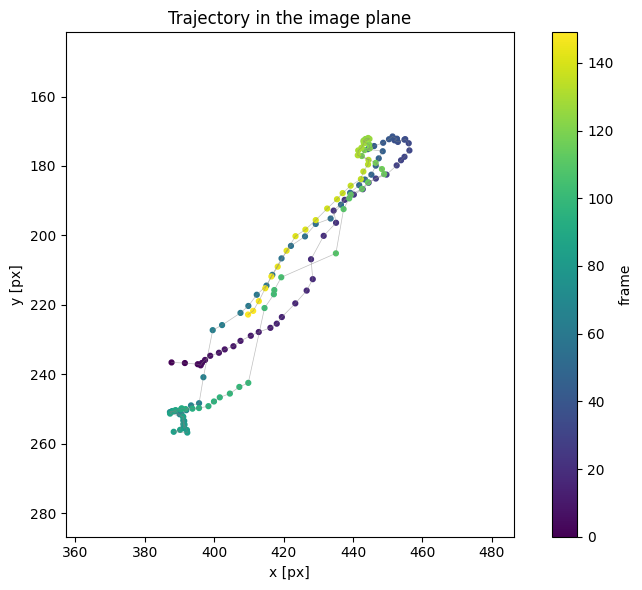

In [13]:
HERE = Path.cwd()                       # Notebook runs from the folder it is saved in
videoPath = HERE / "Assignment 1-class" / "test" / "color_video" / "test_swingingload.avi"
modelPath = HERE / "YOLO_swinging_load.pt"
outputDir = HERE / "tracking"
outputDir.mkdir(exist_ok=True) 


model = YOLO(modelPath)             # Loading the trained YOLO model
confTresh = 0.5                     # Confidence threshold for detection
video = cv2.VideoCapture(str(videoPath)) # Open the video file

if not video.isOpened():
    raise FileNotFoundError(f"Cannot open {videoPath}") # Recommended by AI to raise an error if the video cannot be opened, due to cv2 retruning None instead of raising an error

fps = video.get(cv2.CAP_PROP_FPS) or 30
W = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Video: {videoPath}, {W}x{H} px, {fps:.1f} fps, model: {modelPath}, conf={confTresh}")
# -------------------------------------------------------------------

log = []            # (frame, t, cx, cy, w, h, conf)
trail = []          # centres drawn on the video
i = 0
while True:
    ok, frame = video.read()
    if not ok:
        break
        
    result = model.predict(frame, conf=confTresh, verbose=False)[0]

    if len(result.boxes):
        box = result.boxes[result.boxes.conf.argmax()]                                      # one load -> keep the most confident box
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()                                          # Fetching the lower left corner and upper right corner of the bounding box
        center_x, center_y = (x1 + x2) / 2, (y1 + y2) / 2                                   # Finding the centre of the bounding box
        log.append((i, i / fps, center_x, center_y, x2 - x1, y2 - y1, float(box.conf[0])))  # Recording the tracing data
    else:
        log.append((i, i / fps, np.nan, np.nan, np.nan, np.nan, np.nan))

    i += 1

video.release();  cv2.destroyAllWindows()

log = np.array(log)
np.savetxt(outputDir / "trajectory.csv", log, delimiter=",", fmt="%.3f",
           header="frame,t_s,center_x,center_y,w,h,conf", comments="")
det = ~np.isnan(log[:, 2])
print(f"{i} frames, load detected in {det.sum()} ({100 * det.mean():.1f} %)")
print(f"saved: {outputDir / 'trajectory.csv'}, {outputDir / 'trajectory.png'}")

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(log[det, 2], log[det, 3], c=log[det, 0], cmap="viridis", s=12)
ax.plot(log[det, 2], log[det, 3], color="gray", lw=0.5, alpha=0.5)
pad = 30
ax.set_xlim(np.nanmin(log[:, 2]) - pad, np.nanmax(log[:, 2]) + pad)
ax.set_ylim(np.nanmax(log[:, 3]) + pad, np.nanmin(log[:, 3]) - pad)
ax.set_aspect("equal"); ax.set_xlabel("x [px]"); ax.set_ylabel("y [px]")
ax.set_title("Trajectory in the image plane")
fig.colorbar(sc, ax=ax, label="frame")
plt.tight_layout()
fig.savefig(outputDir / "trajectory.png", dpi=150)
plt.show()

# Q3. Multi object segmentation, tracking and counting:                         10  points

Explore different data-set available freely on internet (https://docs.ultralytics.com/datasets ). Get familiar with them. Then choose a data set and corresponding class of your choice (e.g. CIFAR-10, dataset/COCO data set or KITTI data set / person). Then make a video such that multiple instances of objects are in the scene (e.g. 5 people are the scene). Perform 
(a) instance segmentation, 
(b) counting  - total number of object in scene
(c) and tracking of individual instance of object
(d) draw a region - and count the object in that region

In [15]:
# Directories and paths
HERE      = Path.cwd()                  # Notebook runs from the folder it is saved in
videoDir  = HERE / "Q3"
inputVideo  = videoDir / "pedestrians.mp4"
outputVideo = videoDir / "q3_output.mp4"
modelPath = HERE / "yolo11n-seg.pt"     # Pretrained COCO segmentation model (downloaded automatically if missing)

# Parameters
TARGET_CLASS = 0        # COCO class id: 0 = person
confTresh    = 0.4      # Confidence threshold for detection (default in ultralytics is 0.25)
TRACKER      = "bytetrack.yaml"   # Tracking algorithm recommended by AI, alternative: "botsort.yaml" (slower, more robust to occlusion)
SHOW         = False    # Show live window (cv2.imshow can freeze Jupyter; set True only when running as a script) while processing (press q to stop)


model = YOLO(modelPath)                                                     # Loading the segmentation model
cap = cv2.VideoCapture(str(inputVideo))                                     # Opening the input video (OpenCV wants a str, not Path)
if not cap.isOpened():
    raise FileNotFoundError(f"Could not open {inputVideo}")                 # Failing loudly instead of silently producing an empty output

w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))                                # Frame width in pixels
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))                               # Frame height in pixels
fps = cap.get(cv2.CAP_PROP_FPS) or 30                                       # Frames per second (fallback to 30 if the file does not report it)

REGION = np.array([[0, 0], [w, 0], [w, h // 2], [0, h // 2]], dtype=np.int32)   # Polygon for Q3 d): upper half of the frame, given as corner points (x, y)

writer = cv2.VideoWriter(str(outputVideo), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))  # Output video with the same size and fps as the input

allIds   = set()        # Every track ID seen in the whole video -> total number of unique persons
frameIdx = 0

while True:
    ok, frame = cap.read()                                                  # Reading the next frame
    if not ok:
        break                                                               # End of video
    frameIdx += 1

    # Q3 a) + c): segmentation and tracking in one call
    result = model.track(frame,
                         persist=True,                                      # Keep the tracker state between frames so IDs stay stable
                         tracker=TRACKER,
                         classes=[TARGET_CLASS],                            # Only detect the chosen class
                         conf=confTresh,
                         verbose=False)[0]                                  # track() returns a list with one Results object per frame

    annotated = result.plot()                                               # Drawing masks (a), boxes and track IDs (c) onto a copy of the frame

    nInFrame  = 0                                                           # Q3 b): objects in the scene in this frame
    nInRegion = 0                                                           # Q3 d): objects inside REGION in this frame

    if result.boxes is not None and result.boxes.id is not None:            # id is None if the tracker has not assigned IDs yet (e.g. no detections)
        boxes = result.boxes.xyxy.cpu().numpy()                             # Bounding boxes as (x1, y1, x2, y2) in pixels
        ids   = result.boxes.id.int().cpu().numpy()                         # Track ID for each box
        nInFrame = len(ids)                                                 # Number of detected persons in this frame
        allIds.update(ids.tolist())                                         # Remembering the IDs for the total count

        # Q3 d): count objects whose box centre lies inside the region
        for (x1, y1, x2, y2), tid in zip(boxes, ids):
            centerX, centerY = int((x1 + x2) / 2), int((y1 + y2) / 2)       # Using the box centre as the position of the person
            inside = cv2.pointPolygonTest(REGION, (centerX, centerY), False) >= 0   # +1 inside, 0 on the edge, -1 outside
            if inside:
                nInRegion += 1
            cv2.circle(annotated, (centerX, centerY), 5, (0, 255, 0) if inside else (0, 0, 255), -1)   # Green dot inside region, red outside
            cv2.putText(annotated, f"ID {tid}", (centerX + 8, centerY), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)

    # 3. Draw region and counters ------------------------------------------------------------------
    cv2.polylines(annotated, [REGION], isClosed=True, color=(255, 0, 255), thickness=3)   # Drawing the region polygon in magenta
    info = [f"Frame: {frameIdx}",
            f"(b) In scene now: {nInFrame}",
            f"(b) Unique tracked so far: {len(allIds)}",
            f"(d) In region: {nInRegion}"]
    for i, text in enumerate(info):
        cv2.putText(annotated, text, (20, 40 + 35 * i), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2, cv2.LINE_AA)  # One text line per counter

    writer.write(annotated)                                                 # Writing the annotated frame to the output video
    if SHOW:
        cv2.imshow("Q3", annotated)
        if cv2.waitKey(1) & 0xFF == ord("q"):                               # Press q to stop early
            break

# 4. Clean up --------------------------------------------------------------------------------------
cap.release()
writer.release()
cv2.destroyAllWindows()
print(f"Done. Frames: {frameIdx}, unique persons tracked: {len(allIds)}, saved to {outputVideo}")

Done. Frames: 217, unique persons tracked: 14, saved to c:\Users\ssgje\Documents\School\MAS512 - Computer Vision and Embedded AI\Assignments\MAS512\Assignment 1\Q3\q3_output.mp4


# Q4. Classification                                                        10  marks
Given the data-set fault-classification-class. Perform the following
(a) Develop ML model to determine the state of health of asset (in this case motor).
(b) Show, train and val loss, confusion matrix and classification report
(c) Consider the one in the class as baseline and compare your model with it. Summarize in terms of
model parameter, inference time, accuracy, precision, recall, F1 score


Found 1800 files belonging to 2 classes.
Using 1440 files for training.
Found 1800 files belonging to 2 classes.
Using 360 files for validation.
Found 200 files belonging to 2 classes.
The classes are ['00_15', '10_15']
Model: "baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizatio  (None, 60, 175, 3)       7         
 n)                                                              
                                                                 
 conv2d (Conv2D)             (None, 58, 173, 4)        112       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 29, 86, 4)        0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 27, 84, 8)         296       
                                    

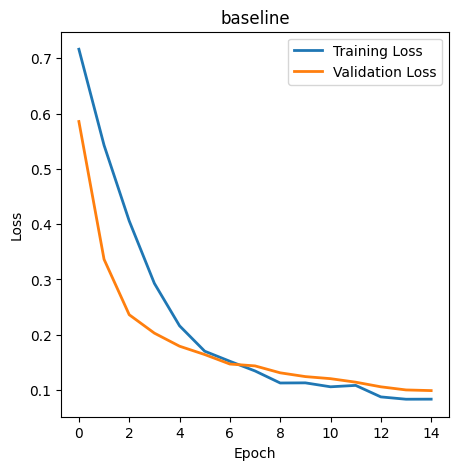

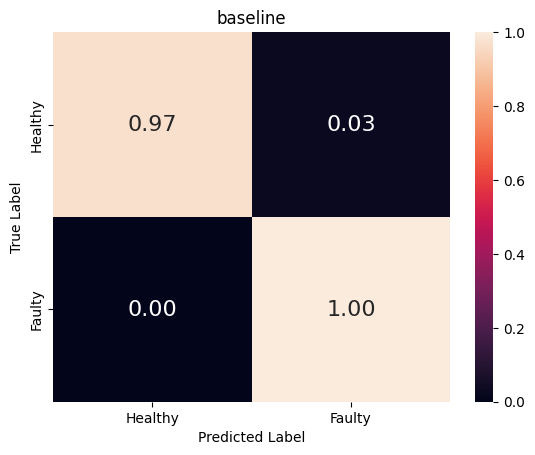

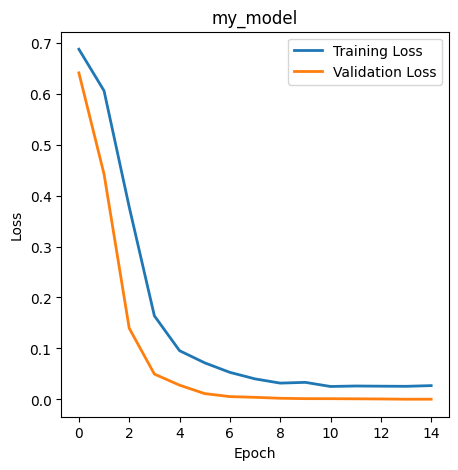

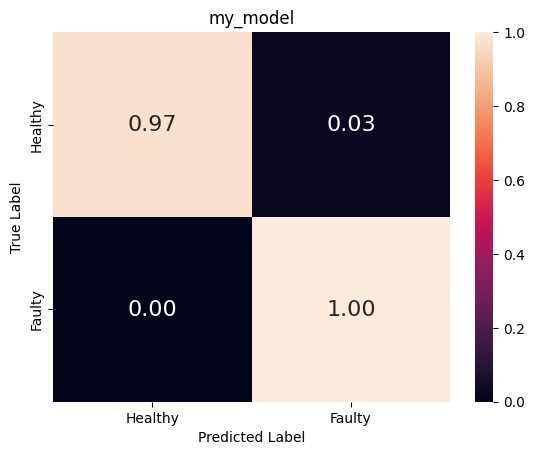

In [16]:
DATA_DIR = os.path.join("Assignment 1-class", "fault-classification-class")
n_row = 60
n_col = 175
image_size = (n_row, n_col)
batch_size = 8
EPOCHS = 15

 # Data
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "training"),
    labels='inferred',
    color_mode='rgb',
    batch_size=batch_size,
    image_size=image_size,
    shuffle=True,
    seed=120,
    validation_split=0.2,   
    subset='training',
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "training"),
    color_mode='rgb',
    batch_size=batch_size,
    image_size=image_size,
    shuffle=False,
    seed=120,
    validation_split=0.2,  
    subset='validation',
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "testing"),   
    color_mode='rgb',
    batch_size=batch_size,
    image_size=image_size,
    shuffle=False,
    seed=120,
)

class_names = train_ds.class_names
print("The classes are", class_names)


# Baseline: model from the lab notebook
normalizer = tf.keras.layers.Normalization(axis=-1) 
normalizer.adapt(train_ds.map(lambda x, y: x))

baseline = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_row, n_col, 3)),
    normalizer,
    tf.keras.layers.Conv2D(4, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(8, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(8, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu'),
    tf.keras.layers.Dense(16, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu'),
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(64, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu'),
    tf.keras.layers.Dense(64, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(2, activation='softmax'),
], name="baseline")

# our model: 
my_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_row, n_col, 3)),
    tf.keras.layers.Rescaling(1.0 / 255),              
    tf.keras.layers.Conv2D(8, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(2, activation="softmax"),
], name="my_model")


# Train 
y_true = np.concatenate([y for x, y in test_ds], axis=0)
results = {}

for model in [baseline, my_model]:
    name = model.name
    model.summary()

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"],)
    history = model.fit(train_ds, epochs=EPOCHS, verbose=1, validation_data=val_ds)

    # (b) 
    plt.figure(figsize=(5, 5))
    plt.plot(range(EPOCHS), history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(range(EPOCHS), history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.legend(loc='upper right')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(name)
    plt.savefig(f"q4_{name}_loss.png", dpi=150)

    start = time.time()
    y_prob = model.predict(test_ds)
    inference_time = (time.time() - start) / len(y_true) * 1000   # ms per image
    y_pred = np.argmax(y_prob, axis=-1)

    cm = confusion_matrix(y_true, y_pred)
    cm_n = cm / cm.sum(axis=1)[:, np.newaxis]
    plt.figure()
    sn.heatmap(cm_n, xticklabels=['Healthy', 'Faulty'], yticklabels=['Healthy', 'Faulty'], annot=True, fmt='.2f', annot_kws={"size": 16})
    plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title(name)
    plt.savefig(f"q4_{name}_confusion_matrix.png", dpi=150)

    print(f"\n===== {name} =====")
    print(classification_report(y_true, y_pred))

    # (c) 
    results[name] = [model.count_params(),
                     inference_time,
                     accuracy_score(y_true, y_pred),
                     precision_score(y_true, y_pred),
                     recall_score(y_true, y_pred),
                     f1_score(y_true, y_pred)]

print("\nModel        Parameters  Inference [ms]  Accuracy  Precision  Recall     F1")
for name, r in results.items():
    print(f"{name:<12} {r[0]:>10} {r[1]:>15.3f} {r[2]:>9.3f} {r[3]:>10.3f} {r[4]:>7.3f} {r[5]:>6.3f}")

plt.show()

# Q5. Classification                                                        20  
Download CFAR-10 dataset (https://www.tensorflow.org/datasets/catalog/cifar10). Perform the classification task on this dataset 
(a) Use model fusion (use two or models to extract feature and combine them), 
(b) Use transfer learning
(c) Use finetuning
(d) Compare different methods (a) - (c) in terms of typical KPIs often used for classification

In [17]:
SEED = 42
IMG_SIZE = 96
BATCH_SIZE = 64
EPOCHS = 30
VAL_FRACTION = 0.10   

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=VAL_FRACTION,stratify=y_train_full, random_state=SEED)

n_total = len(x_train_full) + len(x_test)
split_table = {
    "Total": n_total,
    "Training": len(x_train),
    "Validation": len(x_val),
    "Test": len(x_test),
}
print("\nDataset distribution:")
for k, v in split_table.items():
    print(f"  {k:<11} {v:>6}  ({100 * v / n_total:5.1f} %)")

# Made by AI. It only partly shuffles to save memory andtime 
def make_ds(x, y, training):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10_000, seed=SEED)

    def _prep(img, label):
        img = tf.image.resize(tf.cast(img, tf.float32), (IMG_SIZE, IMG_SIZE))
        if training:
            # Reccomended from claude to avaid overfitting. It rotates the image and flips it horizontally
            img = tf.image.random_flip_left_right(img)
        return img, label

    return (ds.map(_prep, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(BATCH_SIZE)
              .prefetch(tf.data.AUTOTUNE))

train_ds = make_ds(x_train, y_train, training=True)
val_ds = make_ds(x_val, y_val, training=False)
test_ds = make_ds(x_test, y_test, training=False)


Dataset distribution:
  Total        60000  (100.0 %)
  Training     45000  ( 75.0 %)
  Validation    5000  (  8.3 %)
  Test         10000  ( 16.7 %)


### a) model fusion

Model: "fusion_mobilenetv2_resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image (InputLayer)             [(None, 96, 96, 3)]  0           []                               
                                                                                                  
 tf.math.truediv (TFOpLambda)   (None, 96, 96, 3)    0           ['image[0][0]']                  
                                                                                                  
 tf.__operators__.getitem (Slic  (None, 96, 96, 3)   0           ['image[0][0]']                  
 ingOpLambda)                                                                                     
                                                                                                  
 tf.math.subtract (TFOpLambda)  (None, 96, 96, 3)    0           ['tf.ma

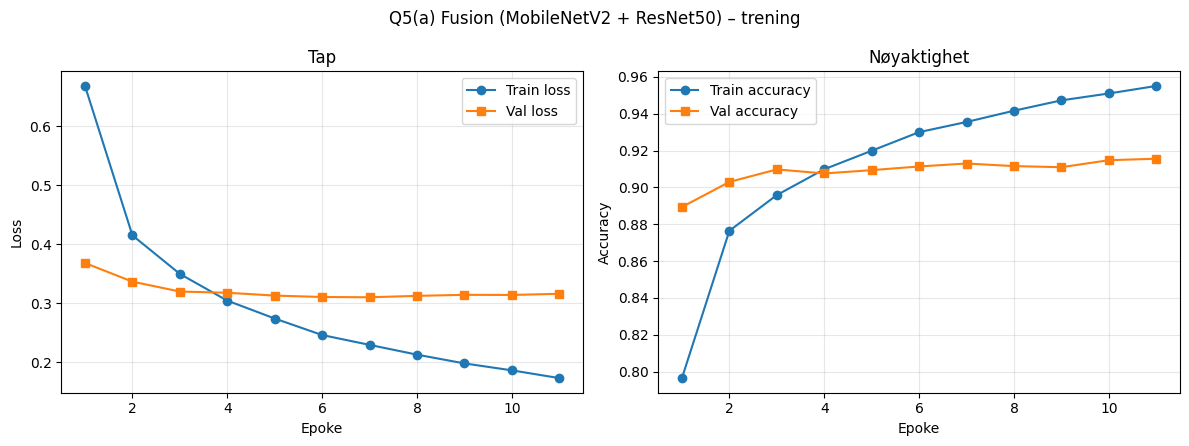

157/157 [==============================] - 2s 12ms/step

Test: accuracy 0.909 | precision 0.910 | recall 0.909 | F1 0.909

              precision    recall  f1-score   support

    airplane      0.918     0.935     0.926      1000
  automobile      0.943     0.951     0.947      1000
        bird      0.922     0.881     0.901      1000
         cat      0.826     0.828     0.827      1000
        deer      0.865     0.897     0.881      1000
         dog      0.872     0.862     0.867      1000
        frog      0.927     0.942     0.935      1000
       horse      0.933     0.918     0.925      1000
        ship      0.937     0.956     0.947      1000
       truck      0.953     0.923     0.938      1000

    accuracy                          0.909     10000
   macro avg      0.910     0.909     0.909     10000
weighted avg      0.910     0.909     0.909     10000



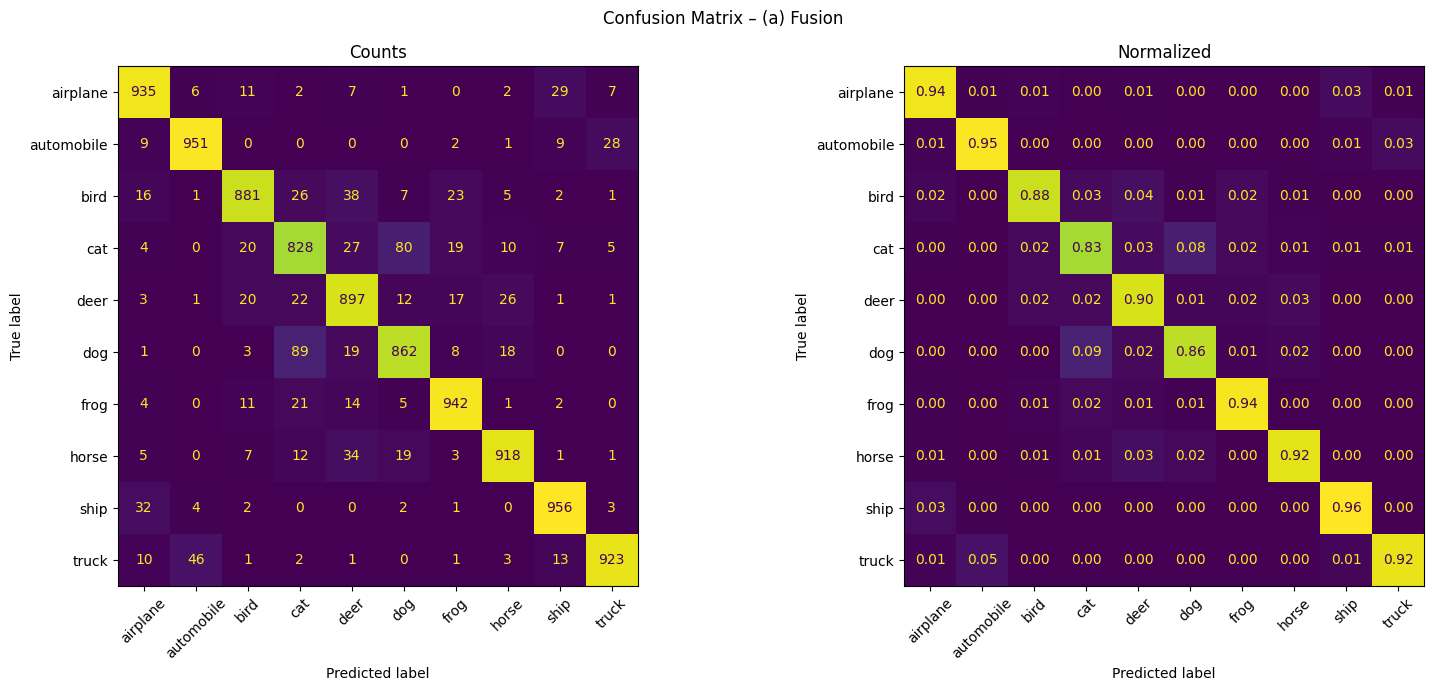

In [18]:
tf.keras.backend.clear_session()        
tf.keras.utils.set_random_seed(SEED)

LR = 1e-4

def build_fusion_model():
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")

    # Model 1: MobileNetV2
    x1 = tf.keras.applications.mobilenet_v2.preprocess_input(inp)
    mobilenet = tf.keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    mobilenet.trainable = False                      
    f1 = mobilenet(x1, training=False)               
    f1 = tf.keras.layers.GlobalAveragePooling2D(name="gap_mobilenet")(f1)  

    # Model 2: ResNet50
    x2 = tf.keras.applications.resnet50.preprocess_input(inp)
    resnet = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    resnet.trainable = False
    f2 = resnet(x2, training=False)
    f2 = tf.keras.layers.GlobalAveragePooling2D(name="gap_resnet")(f2)

    # Fusion
    x = tf.keras.layers.Concatenate(name="feature_fusion")([f1, f2])
    x = tf.keras.layers.BatchNormalization(name="bn_fusion")(x)
    x = tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4), name="dense_256")(x)
    x = tf.keras.layers.Dropout(0.4, name="dropout")(x)
    out = tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax", name="output")(x)           

    return tf.keras.Model(inp, out, name="fusion_mobilenetv2_resnet50")

model = build_fusion_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

trainable_params = int(sum(np.prod(w.shape) for w in model.trainable_weights))
total_params = int(model.count_params())
print(f"\nParameters: total {total_params:,} | trainable {trainable_params:,}")

# Training
callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),]

t0 = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)
train_time = time.time() - t0
epochs_run = len(history.history["loss"])
print(f"\nTraining time: {train_time:.1f} s over {epochs_run} epochs")

# Loss curve
h = history.history
ep = np.arange(1, epochs_run + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(ep, h["loss"], "o-", label="Train loss")
ax[0].plot(ep, h["val_loss"], "s-", label="Val loss")
ax[0].set_xlabel("Epoke"); ax[0].set_ylabel("Loss"); ax[0].set_title("Tap")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, h["accuracy"], "o-", label="Train accuracy")
ax[1].plot(ep, h["val_accuracy"], "s-", label="Val accuracy")
ax[1].set_xlabel("Epoke"); ax[1].set_ylabel("Accuracy"); ax[1].set_title("Nøyaktighet")
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.suptitle("Q5(a) Fusion (MobileNetV2 + ResNet50) – trening")
fig.tight_layout()
plt.show()

# Evaluation on test set
y_prob = model.predict(test_ds)          # probabilities from softmax
y_pred = np.argmax(y_prob, axis=1)       # class with the highest probability

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
print(f"\nTest: accuracy {acc:.3f} | precision {prec:.3f} | recall {rec:.3f} | F1 {f1:.3f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

# Confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=CLASS_NAMES).plot(ax=ax[0], xticks_rotation=45, colorbar=False)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"), display_labels=CLASS_NAMES).plot(ax=ax[1], xticks_rotation=45, colorbar=False, values_format=".2f")
ax[0].set_title("Counts"); ax[1].set_title("Normalized")
fig.suptitle("Confusion Matrix – (a) Fusion")
fig.tight_layout()
plt.show()

# KPIs used for comparison in (d)
results = {}
results["(a) Fusion"] = {
    "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
    "total_params": total_params, "trainable_params": trainable_params,
    "train_time_s": train_time, "epochs": epochs_run,
}


### b) transfer learning

Model: "transfer_learning_mobilenetv2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 96, 96, 3)]       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 96, 96, 3)        0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 96, 96, 3)        0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_96 (Functi  (None, 3, 3, 1280)       2257984   
 onal)                                                           
                                                                 
 gap_mobilenet (GlobalAverag  (None, 1280)             0         
 ePooling2D)                         

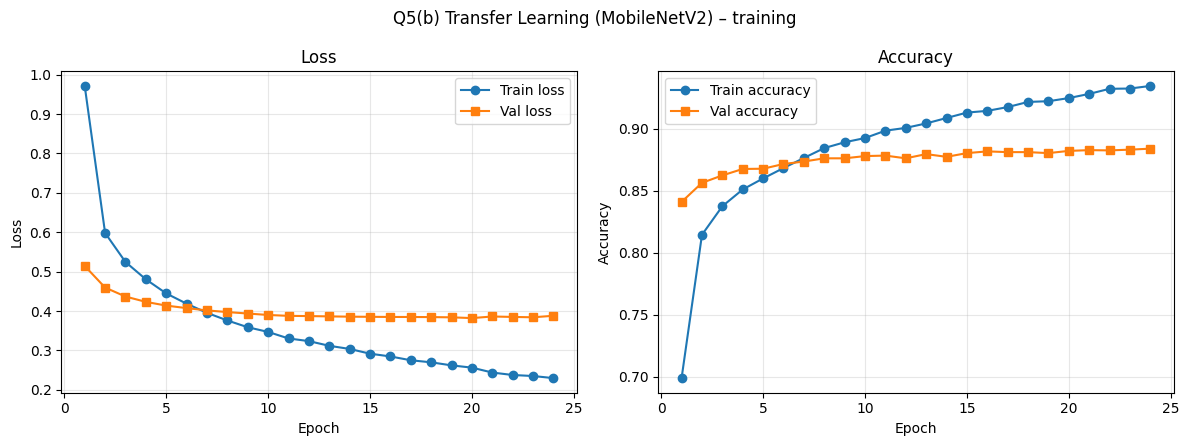

157/157 [==============================] - 1s 3ms/step

Test: accuracy 0.876 | precision 0.875 | recall 0.876 | F1 0.875

              precision    recall  f1-score   support

    airplane      0.875     0.892     0.884      1000
  automobile      0.941     0.924     0.932      1000
        bird      0.884     0.836     0.859      1000
         cat      0.781     0.754     0.767      1000
        deer      0.841     0.856     0.848      1000
         dog      0.827     0.816     0.821      1000
        frog      0.887     0.917     0.902      1000
       horse      0.883     0.897     0.890      1000
        ship      0.915     0.939     0.927      1000
       truck      0.919     0.925     0.922      1000

    accuracy                          0.876     10000
   macro avg      0.875     0.876     0.875     10000
weighted avg      0.875     0.876     0.875     10000



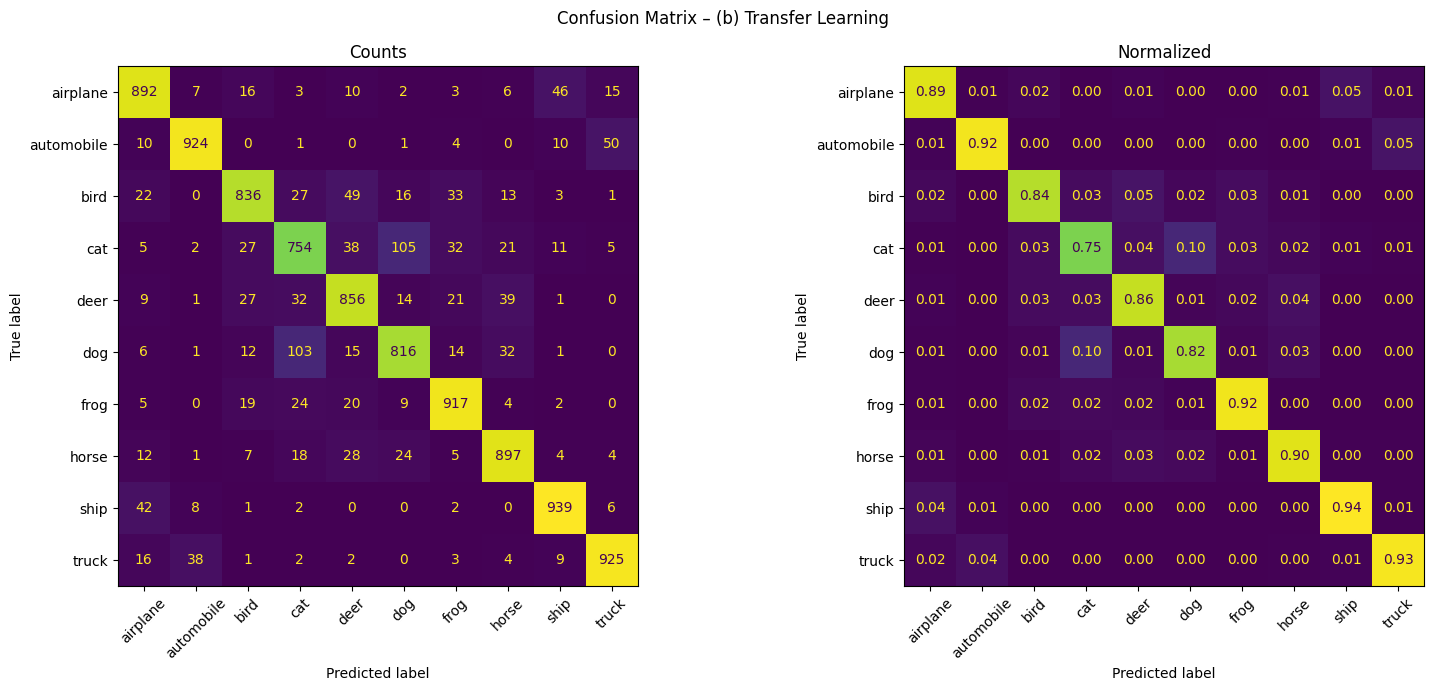

In [19]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

LR = 1e-4

# model
def build_transfer_learning_model():
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")

    # Model 1: MobileNetV2
    x1 = tf.keras.applications.mobilenet_v2.preprocess_input(inp)
    mobilenet = tf.keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    mobilenet.trainable = False                      
    x = mobilenet(x1, training=False)               
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap_mobilenet")(x)  # 1280
    x = tf.keras.layers.BatchNormalization(name="bn_head")(x)
    x = tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4), name="dense_256")(x)
    x = tf.keras.layers.Dropout(0.4, name="dropout")(x)
    out = tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax", name="output")(x)           

    return tf.keras.Model(inp, out, name="transfer_learning_mobilenetv2")

model = build_transfer_learning_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

trainable_params = int(sum(np.prod(w.shape) for w in model.trainable_weights))
total_params = int(model.count_params())
print(f"\nParameters: total {total_params:,} | trainable {trainable_params:,}")

# Training
callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),]

t0 = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)
train_time = time.time() - t0
epochs_run = len(history.history["loss"])
print(f"\nTraining time: {train_time:.1f} s over {epochs_run} epochs")

# loss curve
h = history.history
ep = np.arange(1, epochs_run + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(ep, h["loss"], "o-", label="Train loss")
ax[0].plot(ep, h["val_loss"], "s-", label="Val loss")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].set_title("Loss")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, h["accuracy"], "o-", label="Train accuracy")
ax[1].plot(ep, h["val_accuracy"], "s-", label="Val accuracy")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].set_title("Accuracy")
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.suptitle("Q5(b) Transfer Learning (MobileNetV2) – training")
fig.tight_layout()
plt.show()

# Evaluation on test set
y_prob = model.predict(test_ds)          # probabilities from softmax
y_pred = np.argmax(y_prob, axis=1)       # class with the highest probability

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
print(f"\nTest: accuracy {acc:.3f} | precision {prec:.3f} | recall {rec:.3f} | F1 {f1:.3f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

# Confusion matrix 
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),display_labels=CLASS_NAMES).plot(ax=ax[0], xticks_rotation=45, colorbar=False)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"), display_labels=CLASS_NAMES).plot(ax=ax[1], xticks_rotation=45, colorbar=False, values_format=".2f")
ax[0].set_title("Counts"); ax[1].set_title("Normalized")
fig.suptitle("Confusion Matrix – (b) Transfer Learning")
fig.tight_layout()
plt.show()

# Store KPIs for comparison in (d)
results["(b) Transfer learning"] = {
    "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
    "total_params": total_params, "trainable_params": trainable_params,
    "train_time_s": train_time, "epochs": epochs_run,
}


### c) fine tuning

Model: "finetuning_mobilenetv2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 96, 96, 3)]       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 96, 96, 3)        0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 96, 96, 3)        0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_96 (Functi  (None, 3, 3, 1280)       2257984   
 onal)                                                           
                                                                 
 gap_mobilenet (GlobalAverag  (None, 1280)             0         
 ePooling2D)                                

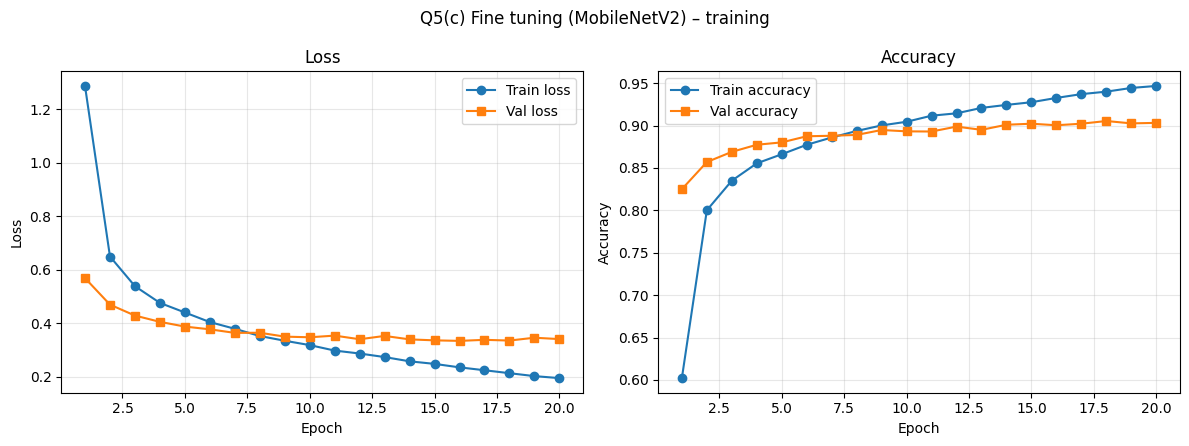

157/157 [==============================] - 1s 3ms/step

Test: accuracy 0.897 | precision 0.899 | recall 0.897 | F1 0.898

              precision    recall  f1-score   support

    airplane      0.914     0.896     0.905      1000
  automobile      0.969     0.930     0.949      1000
        bird      0.900     0.870     0.885      1000
         cat      0.767     0.842     0.803      1000
        deer      0.844     0.901     0.871      1000
         dog      0.876     0.818     0.846      1000
        frog      0.934     0.910     0.922      1000
       horse      0.952     0.901     0.926      1000
        ship      0.923     0.951     0.937      1000
       truck      0.914     0.953     0.933      1000

    accuracy                          0.897     10000
   macro avg      0.899     0.897     0.898     10000
weighted avg      0.899     0.897     0.898     10000



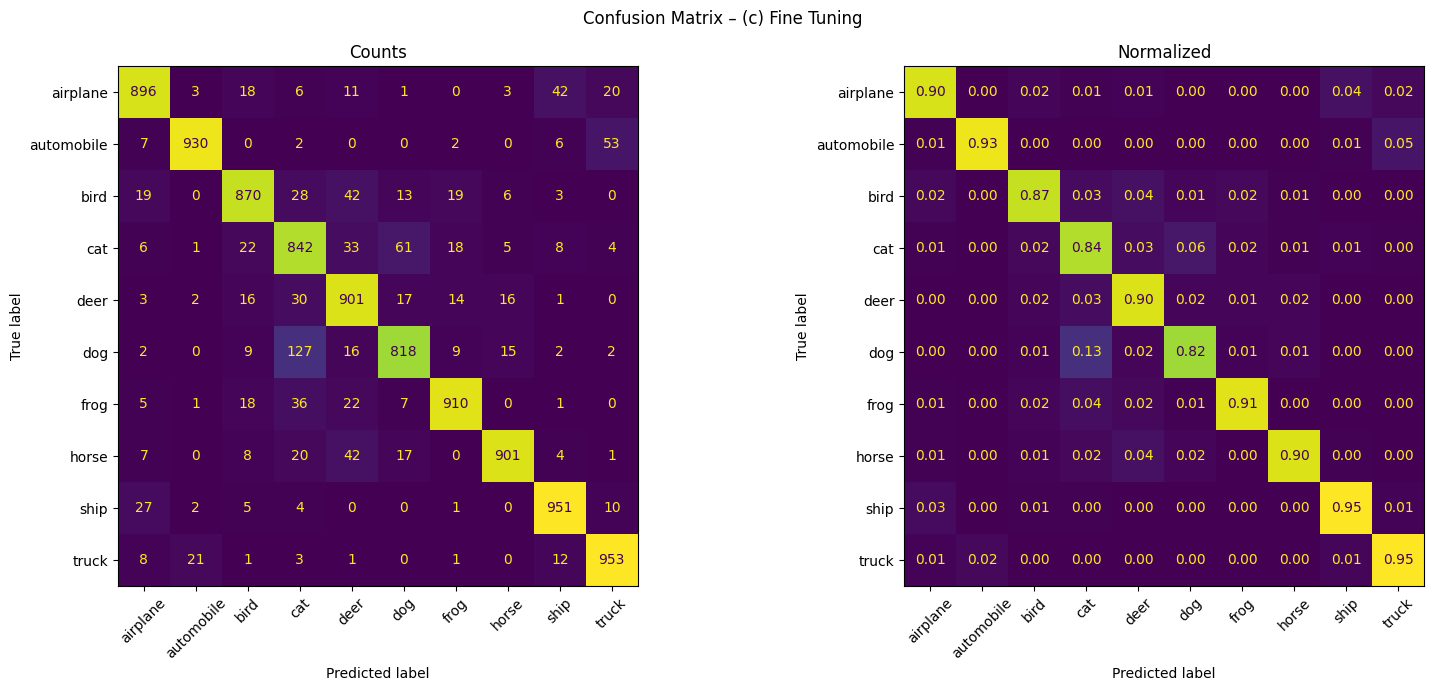

In [20]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

LR = 1e-5  
FINE_TUNE_LAYERS = 25 

# model
def build_finetuning_model():
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inp)

    mobilenet = tf.keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    mobilenet.trainable = True
    for layer in mobilenet.layers[:-FINE_TUNE_LAYERS]:
        layer.trainable = False            
    x = mobilenet(x, training=False)      

    x = tf.keras.layers.GlobalAveragePooling2D(name="gap_mobilenet")(x)    # 1280 features
    x = tf.keras.layers.BatchNormalization(name="bn_head")(x)
    x = tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4), name="dense_256")(x)
    x = tf.keras.layers.Dropout(0.4, name="dropout")(x)
    out = tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax", name="output")(x)

    return tf.keras.Model(inp, out, name="finetuning_mobilenetv2")

model = build_finetuning_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

trainable_params = int(sum(np.prod(w.shape) for w in model.trainable_weights))
total_params = int(model.count_params())
print(f"\nParameters: total {total_params:,} | trainable {trainable_params:,}")

# Training
callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),]

t0 = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)
train_time = time.time() - t0
epochs_run = len(history.history["loss"])
print(f"\nTraining time: {train_time:.1f} s over {epochs_run} epochs")

# loss curve
h = history.history
ep = np.arange(1, epochs_run + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(ep, h["loss"], "o-", label="Train loss")
ax[0].plot(ep, h["val_loss"], "s-", label="Val loss")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].set_title("Loss")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, h["accuracy"], "o-", label="Train accuracy")
ax[1].plot(ep, h["val_accuracy"], "s-", label="Val accuracy")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].set_title("Accuracy")
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.suptitle("Q5(c) Fine tuning (MobileNetV2) – training")
fig.tight_layout()
plt.show()

# Evaluation on test set
y_prob = model.predict(test_ds)          # probabilities from softmax
y_pred = np.argmax(y_prob, axis=1)       # class with highest probability

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
print(f"\nTest: accuracy {acc:.3f} | precision {prec:.3f} | recall {rec:.3f} | F1 {f1:.3f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

# Confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),display_labels=CLASS_NAMES).plot(ax=ax[0], xticks_rotation=45, colorbar=False)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"),display_labels=CLASS_NAMES).plot(ax=ax[1], xticks_rotation=45, colorbar=False, values_format=".2f")
ax[0].set_title("Counts"); ax[1].set_title("Normalized")
fig.suptitle("Confusion Matrix – (c) Fine Tuning")
fig.tight_layout()
plt.show()

# Store KPIs for comparison in (d)
results["(c) Fine tuning"] = {
    "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
    "total_params": total_params, "trainable_params": trainable_params,
    "train_time_s": train_time, "epochs": epochs_run,
}

### d) comparison

Method                    Total params   Trainable    Acc   Prec    Rec     F1  Epochs  Time (s)
------------------------------------------------------------------------------------------------
(a) Fusion                  26,713,802     861,450  0.909  0.910  0.909  0.909      11       125
(b) Transfer learning        2,593,610     333,066  0.876  0.875  0.876  0.875      24        96
(c) Fine tuning              2,593,610   1,694,986  0.897  0.899  0.897  0.898      20        98


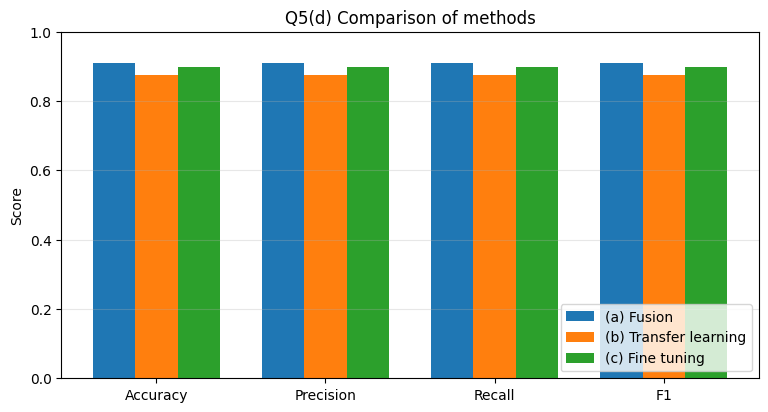

In [21]:
# run a), b) and c) and then run this cell to compare the results
header = (f"{'Method':<24}{'Total params':>14}{'Trainable':>12}{'Acc':>7}{'Prec':>7}"
          f"{'Rec':>7}{'F1':>7}{'Epochs':>8}{'Time (s)':>10}")
print(header)
print("-" * len(header))
for name, r in results.items():
    print(f"{name:<24}{r['total_params']:>14,}{r['trainable_params']:>12,}"
          f"{r['accuracy']:>7.3f}{r['precision']:>7.3f}{r['recall']:>7.3f}"
          f"{r['f1']:>7.3f}{r['epochs']:>8}{r['train_time_s']:>10.0f}")

# chart
kpis = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(kpis))
w = 0.25
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (name, r) in enumerate(results.items()):
    ax.bar(x + i * w, [r[k] for k in kpis], w, label=name)
ax.set_xticks(x + w)
ax.set_xticklabels(["Accuracy", "Precision", "Recall", "F1"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Q5(d) Comparison of methods")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.show()

# Q6. Autoencoder                                                           10 marks
Given the data-set fault-classification-class, 
Use Auto encoder to compress the data to latent space and reconstruct it back. Show the following for random 10 iamges from each class
(a) Original image
(b) Latent vector
(c) Reconstructed back image
(d) individual reconstruction error and mean loss for each class.

In [ ]:
DATA_DIR = os.path.join("Assignment 1-class", "fault-classification-class")
IMG_H      = 60      # original image height (same as Q4)
IMG_W      = 175     # original image width  (same as Q4)
LATENT_DIM = 32
EPOCHS     = 50
BATCH_SIZE = 32
N_SHOW     = 10

input_dim = IMG_H * IMG_W    # 60 x 175 = 10500

def load_folder(path):
    ds = keras.utils.image_dataset_from_directory(
        path,
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",   # grayscale to reduce complexity and focus on structural features
        image_size=(IMG_H, IMG_W),  # original size -> no distortion of the aspect ratio
        batch_size=32,
        shuffle=False,
    )
    X, y = [], []
    for img, lab in ds:
        X.append(img.numpy())
        y.append(lab.numpy())
    X = np.concatenate(X) / 255.0
    y = np.concatenate(y)
    X = X.reshape(len(X), input_dim)         # flatten: 60x175 -> 10500
    return X, y, ds.class_names

X_train_full, y_train_full, class_names = load_folder(os.path.join(DATA_DIR, "training"))
X_test, y_test, _ = load_folder(os.path.join(DATA_DIR, "testing"))

# 20 % of the training data as validation (stratified -> both classes in train and val).
# The test set is only used for the final results (a)-(d).
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)

print("Classes:", class_names)
print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

# Encoder: 10500 -> 256 -> 32
encoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(LATENT_DIM, activation="relu"),
], name="encoder")

# Decoder: 32 -> 256 -> 10500
decoder = keras.Sequential([
    layers.Input(shape=(LATENT_DIM,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(input_dim, activation="sigmoid"),  # sigmoid to get an output in the range [0, 1], same range as the input images
], name="decoder")

autoencoder = keras.Sequential([layers.Input(shape=(input_dim,)), encoder, decoder], name="autoencoder")

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# Training
history = autoencoder.fit(X_train, X_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, X_val))

plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend()
plt.title("Autoencoder training")
plt.savefig("q6_loss_curve.png", dpi=150)

# (a)-(d) on 10 random test images from each class
rng = np.random.default_rng(42)
mean_loss = {}

for c, name in enumerate(class_names):
    idx = np.where(y_test == c)[0]
    idx = rng.choice(idx, size=N_SHOW, replace=False)

    x = X_test[idx]                               # (a) original images
    z = encoder.predict(x, verbose=0)             # (b) latent vector
    x_hat = decoder.predict(z, verbose=0)         # (c) reconstruction
    err = np.mean((x - x_hat) ** 2, axis=1)       # (d) MSE per image
    mean_loss[name] = err.mean()

    n = len(idx)
    fig, ax = plt.subplots(3, n, figsize=(2.8 * n, 4.5), squeeze=False)
    for i in range(n):
        ax[0, i].imshow(x[i].reshape(IMG_H, IMG_W), cmap="gray")
        ax[0, i].set_title(f"#{i+1}")
        ax[1, i].imshow(z[i].reshape(4, LATENT_DIM // 4), cmap="viridis")
        ax[2, i].imshow(x_hat[i].reshape(IMG_H, IMG_W), cmap="gray")
        ax[2, i].set_title(f"MSE={err[i]:.4f}", fontsize=8)
        for r in range(3):
            ax[r, i].axis("off")
    ax[0, 0].text(-0.3, 0.5, "(a) Original", transform=ax[0, 0].transAxes,
                  rotation=90, va="center", ha="right")
    ax[1, 0].text(-0.3, 0.5, f"(b) Latent ({LATENT_DIM})", transform=ax[1, 0].transAxes,
                  rotation=90, va="center", ha="right")
    ax[2, 0].text(-0.3, 0.5, "(c) Reconstructed", transform=ax[2, 0].transAxes,
                  rotation=90, va="center", ha="right")
    fig.suptitle(f"Class: {name}   |   mean MSE = {mean_loss[name]:.5f}")
    plt.tight_layout()
    plt.savefig(f"q6_class_{name}.png", dpi=150)

print("\n===== Average reconstruction loss per class =====")
for name, l in mean_loss.items():
    print(f"{name:20s}: {l:.5f}")

plt.figure()
plt.bar(list(mean_loss.keys()), list(mean_loss.values()))
plt.ylabel("Mean MSE"); plt.title("Mean reconstruction loss per class")
plt.savefig("q6_mean_loss_per_class.png", dpi=150)
plt.show()

NameError: name 'os' is not defined